# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/velvetcrystal/heart-attack-risk-prediction-dataset/heart_attack_dataset (1).csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/velvetcrystal/heart-attack-risk-prediction-dataset/heart_attack_dataset (1).csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,patient_id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,...,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk
0,1,59,Male,Asymptomatic,105.0,154.0,0.0,ST-T Abnormality,186.0,1,...,1,Fixed Defect,23.5,Former,Heavy,Moderate,1,1,6.0,0
1,2,50,Male,Non-anginal Pain,102.0,180.0,0.0,Normal,183.0,0,...,0,Reversible Defect,19.3,NaN,Moderate,High,0,0,8.0,0
2,3,61,Male,Atypical Angina,117.0,213.0,1.0,Normal,161.0,0,...,1,Fixed Defect,30.5,Never,Moderate,Low,1,1,2.0,1
3,4,73,Female,Atypical Angina,121.0,208.0,1.0,Normal,150.0,0,...,0,Normal,28.6,Former,Moderate,Moderate,0,0,4.0,0
4,5,49,Male,Non-anginal Pain,106.0,157.0,0.0,Normal,185.0,0,...,0,Reversible Defect,21.4,Former,Moderate,Moderate,0,0,NaN,0


## last Five row

In [4]:
df.tail()

,patient_id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,...,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk
6995,6996,48,Female,Atypical Angina,108.0,127.0,1.0,NaN,167.0,0,...,1,Normal,30.0,Current,Moderate,High,0,0,10.0,0
6996,6997,63,Male,Non-anginal Pain,107.0,194.0,0.0,Left Ventricular Hypertrophy,159.0,0,...,0,Fixed Defect,24.8,Current,NaN,High,1,0,2.0,0
6997,6998,45,Male,Asymptomatic,98.0,119.0,0.0,Left Ventricular Hypertrophy,161.0,0,...,0,Normal,18.7,Current,Heavy,High,1,0,1.0,1
6998,6999,52,Female,Atypical Angina,126.0,195.0,0.0,ST-T Abnormality,172.0,1,...,1,Normal,34.5,Never,Moderate,NaN,0,0,1.0,1
6999,7000,58,Female,Non-anginal Pain,113.0,172.0,1.0,Normal,146.0,0,...,0,Normal,25.5,Former,Moderate,Low,0,1,NaN,1


## Shape of our dataset

In [5]:
df.shape

(7000, 22)

## List out all columns

In [6]:
df.columns

Index(['patient_id', 'age', 'gender', 'chest_pain_type', 'resting_bp',
       'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'oldpeak', 'st_slope', 'num_major_vessels',
       'thalassemia', 'bmi', 'smoking_status', 'alcohol_consumption',
       'physical_activity', 'family_history', 'diabetes', 'stress_level',
       'heart_attack_risk'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

patient_id               int64
age                      int64
gender                  object
chest_pain_type         object
resting_bp             float64
cholesterol            float64
fasting_blood_sugar    float64
resting_ecg             object
max_heart_rate         float64
exercise_angina          int64
oldpeak                float64
st_slope                object
num_major_vessels        int64
thalassemia             object
bmi                    float64
smoking_status          object
alcohol_consumption     object
physical_activity       object
family_history           int64
diabetes                 int64
stress_level           float64
heart_attack_risk        int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           7000 non-null   int64  
 1   age                  7000 non-null   int64  
 2   gender               7000 non-null   object 
 3   chest_pain_type      7000 non-null   object 
 4   resting_bp           6720 non-null   float64
 5   cholesterol          6602 non-null   float64
 6   fasting_blood_sugar  6804 non-null   float64
 7   resting_ecg          6801 non-null   object 
 8   max_heart_rate       6721 non-null   float64
 9   exercise_angina      7000 non-null   int64  
 10  oldpeak              6650 non-null   float64
 11  st_slope             7000 non-null   object 
 12  num_major_vessels    7000 non-null   int64  
 13  thalassemia          7000 non-null   object 
 14  bmi                  6670 non-null   float64
 15  smoking_status       6495 non-null   o

## Check Null Value

In [9]:
df.isnull().sum()

patient_id               0
age                      0
gender                   0
chest_pain_type          0
resting_bp             280
cholesterol            398
fasting_blood_sugar    196
resting_ecg            199
max_heart_rate         279
exercise_angina          0
oldpeak                350
st_slope                 0
num_major_vessels        0
thalassemia              0
bmi                    330
smoking_status         505
alcohol_consumption    405
physical_activity      346
family_history           0
diabetes                 0
stress_level           268
heart_attack_risk        0
dtype: int64

## remove ID column because it is not useful for prediction

In [10]:
df.drop(columns=["patient_id"], inplace=True)

## define numeric columns with missing values

In [11]:
num_cols = [
    "resting_bp",
    "cholesterol",
    "fasting_blood_sugar",
    "max_heart_rate",
    "oldpeak",
    "bmi",
    "stress_level"
]

## define categorical columns with missing values

In [12]:
cat_cols = [
    "resting_ecg",
    "smoking_status",
    "alcohol_consumption",
    "physical_activity"
]

## fill numeric null values with median

In [13]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

## fill categorical null values with mode

In [14]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

## verify all missing values are handled

In [15]:
print(df.isnull().sum())

age                    0
gender                 0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
num_major_vessels      0
thalassemia            0
bmi                    0
smoking_status         0
alcohol_consumption    0
physical_activity      0
family_history         0
diabetes               0
stress_level           0
heart_attack_risk      0
dtype: int64


## Check Dupicate Value

In [16]:
df.duplicated().sum()

np.int64(0)

## Summary

In [17]:
df.describe()

,age,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_angina,oldpeak,num_major_vessels,bmi,family_history,diabetes,stress_level,heart_attack_risk
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,51.919857,116.430000,184.610857,0.245857,173.945000,0.323714,1.260771,0.749143,27.112729,0.287000,0.205714,5.421714,0.420000
std,13.891205,12.930887,32.223231,0.430625,14.820784,0.467926,1.030241,0.985500,4.886959,0.452394,0.404251,2.822134,0.493594
min,18.000000,80.000000,100.000000,0.000000,115.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,1.000000,0.000000
25%,43.000000,108.000000,164.000000,0.000000,164.000000,0.000000,0.500000,0.000000,23.875000,0.000000,0.000000,3.000000,0.000000
50%,52.000000,116.000000,184.000000,0.000000,174.000000,0.000000,1.000000,0.000000,27.100000,0.000000,0.000000,5.000000,0.000000
75%,61.000000,125.000000,206.000000,0.000000,184.000000,1.000000,1.700000,1.000000,30.400000,1.000000,0.000000,8.000000,1.000000
max,90.000000,162.000000,316.000000,1.000000,210.000000,1.000000,6.500000,3.000000,49.400000,1.000000,1.000000,10.000000,1.000000


# EDA

In [18]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

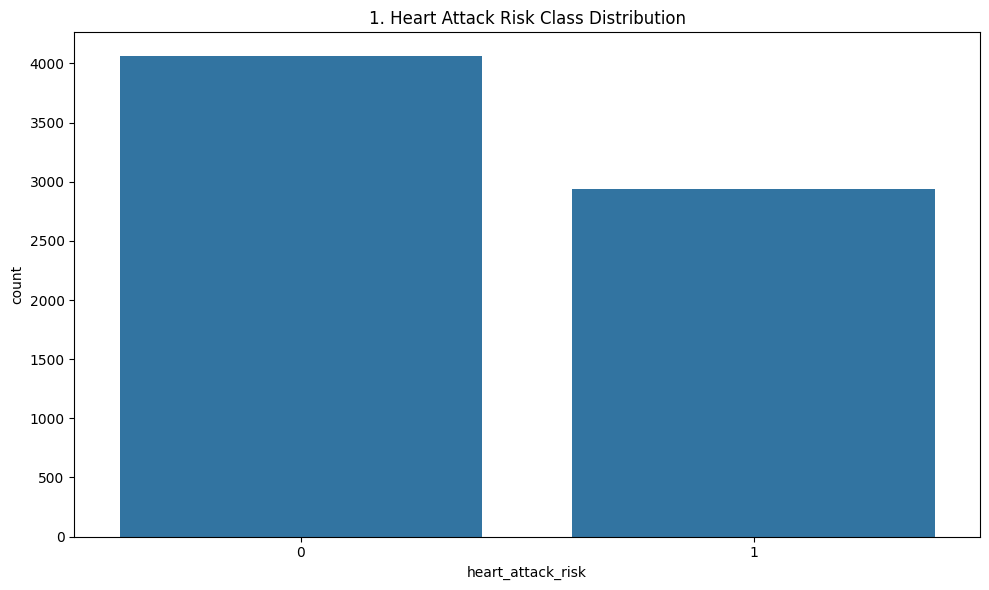

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='heart_attack_risk')
plt.title(f'{plot_no}. Heart Attack Risk Class Distribution')
show_fig()
plot_no += 1

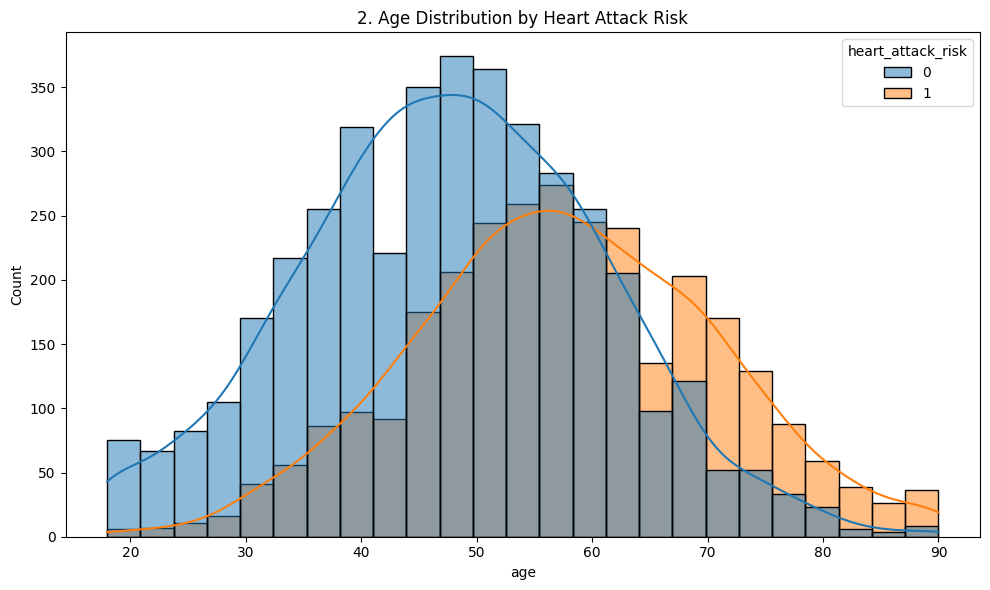

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='heart_attack_risk', kde=True, bins=25)
plt.title(f'{plot_no}. Age Distribution by Heart Attack Risk')
show_fig()
plot_no += 1

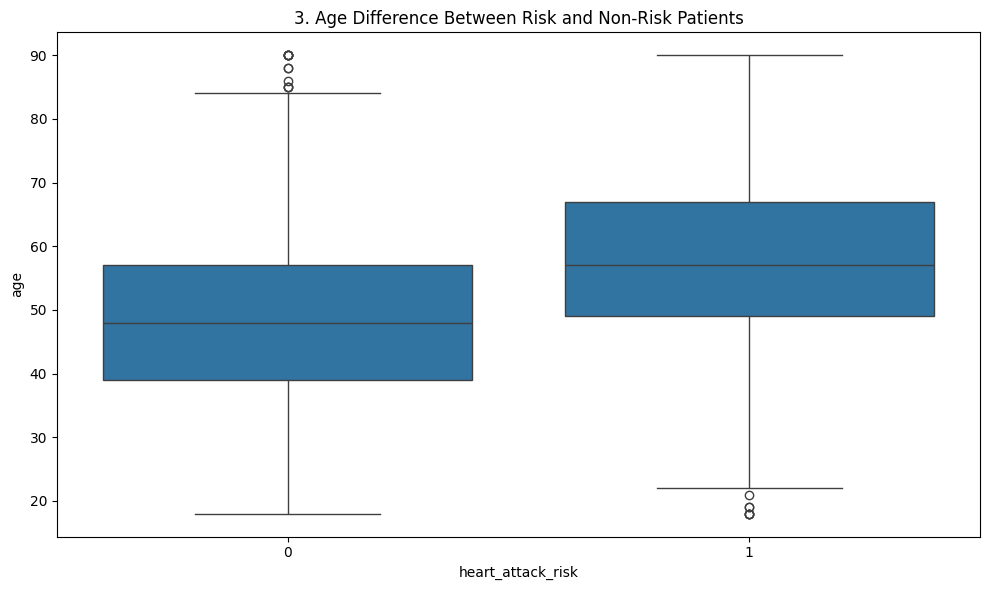

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='heart_attack_risk', y='age')
plt.title(f'{plot_no}. Age Difference Between Risk and Non-Risk Patients')
show_fig()
plot_no += 1

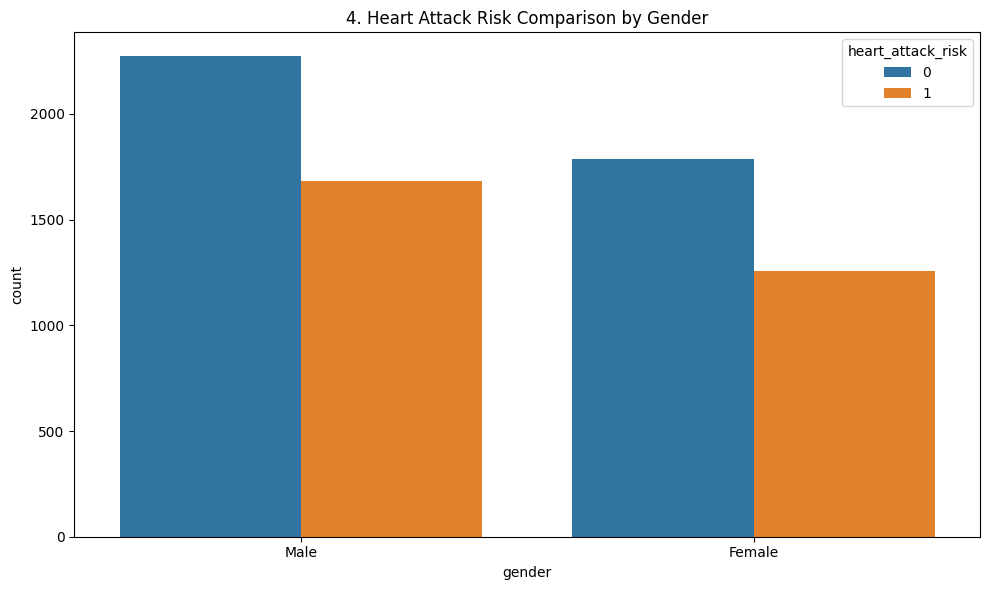

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender', hue='heart_attack_risk')
plt.title(f'{plot_no}. Heart Attack Risk Comparison by Gender')
show_fig()
plot_no += 1

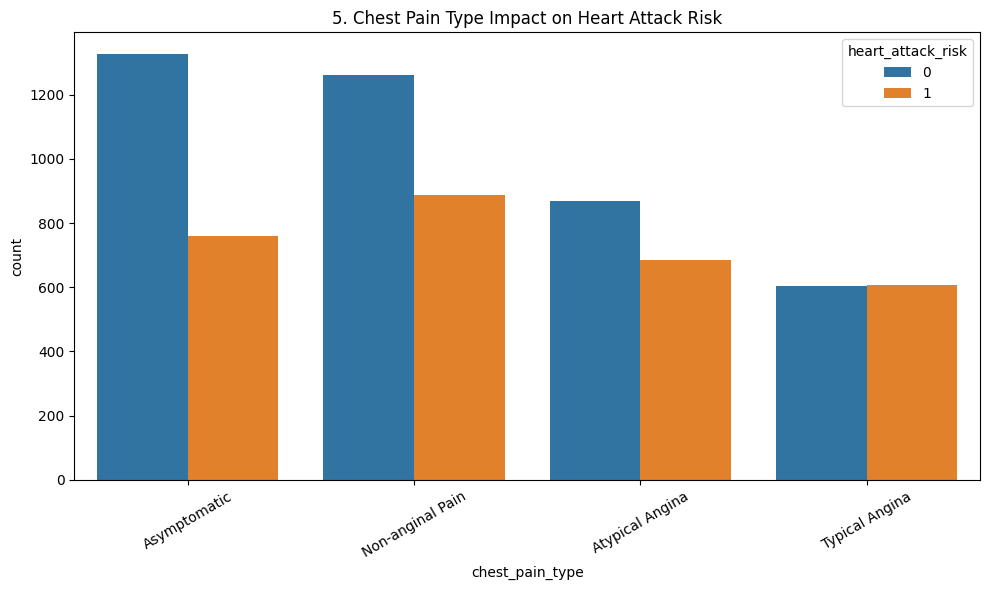

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='chest_pain_type', hue='heart_attack_risk')
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Chest Pain Type Impact on Heart Attack Risk')
show_fig()
plot_no += 1

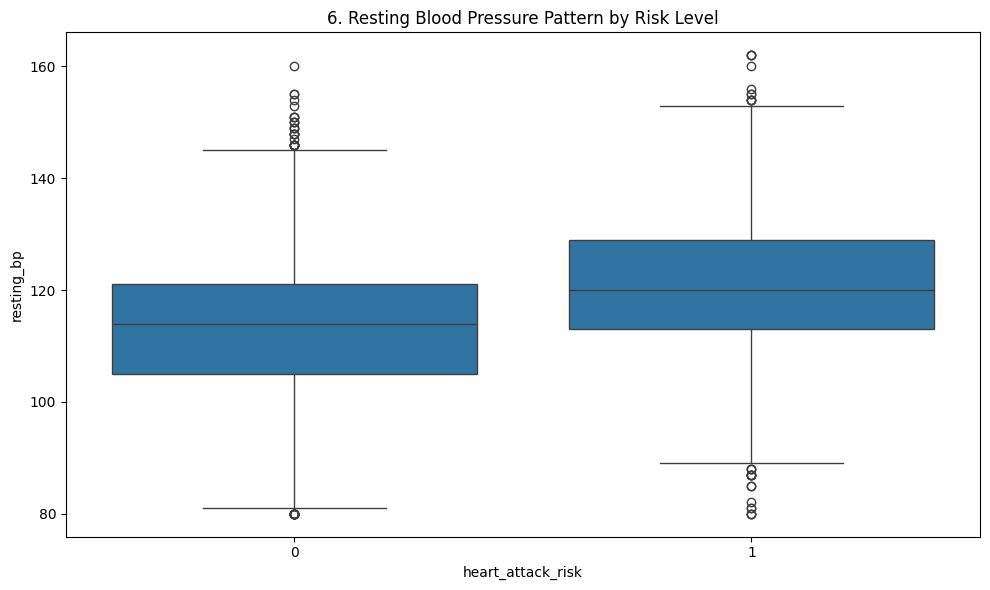

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='heart_attack_risk', y='resting_bp')
plt.title(f'{plot_no}. Resting Blood Pressure Pattern by Risk Level')
show_fig()
plot_no += 1

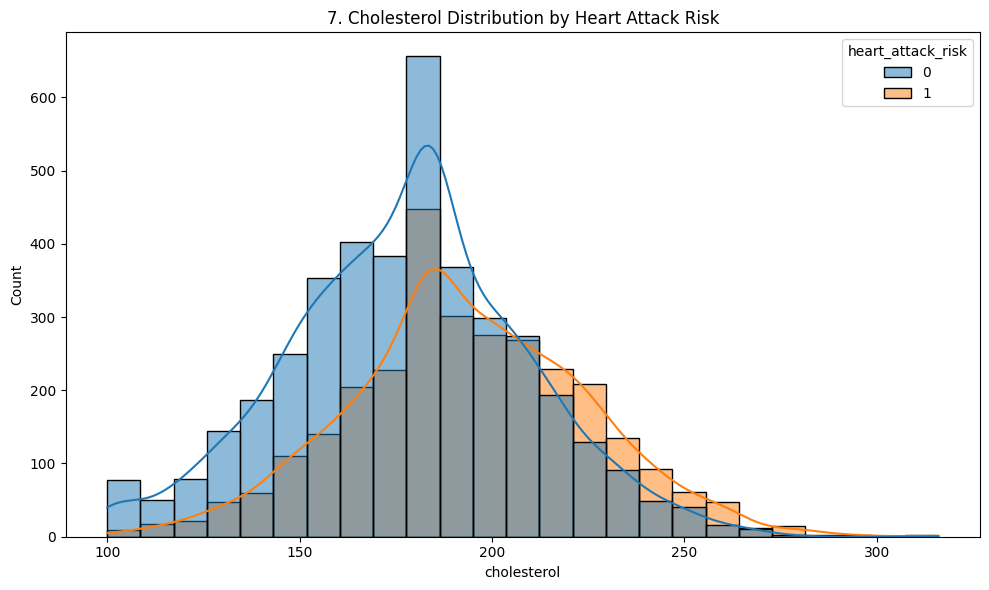

In [25]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='cholesterol', hue='heart_attack_risk', kde=True, bins=25)
plt.title(f'{plot_no}. Cholesterol Distribution by Heart Attack Risk')
show_fig()
plot_no += 1

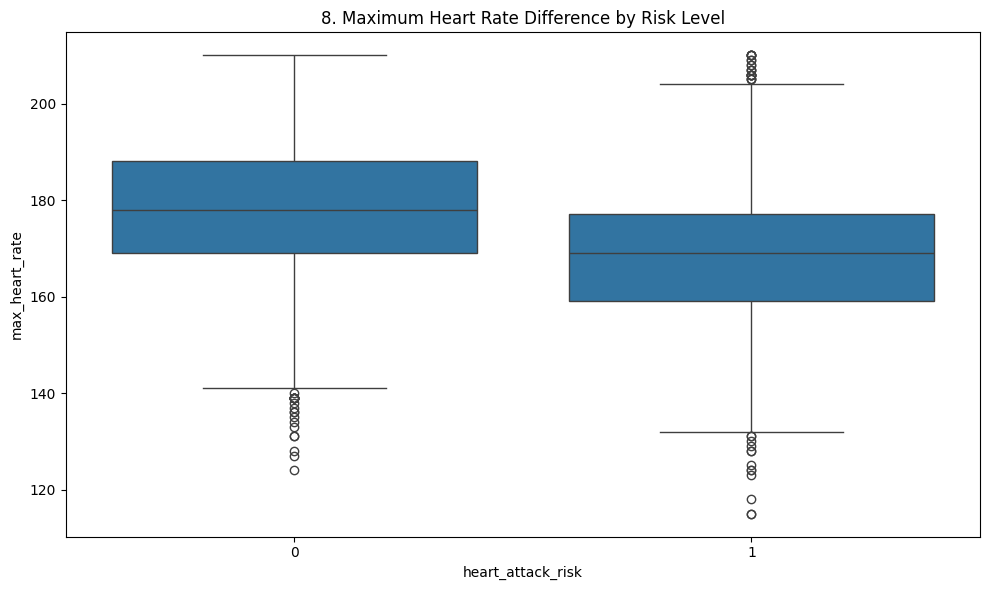

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='heart_attack_risk', y='max_heart_rate')
plt.title(f'{plot_no}. Maximum Heart Rate Difference by Risk Level')
show_fig()
plot_no += 1

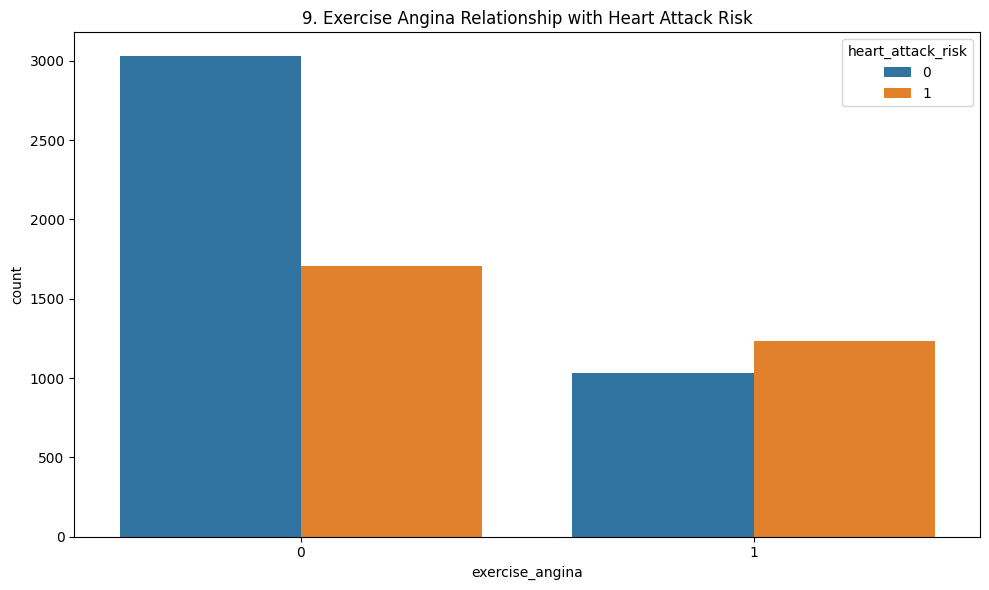

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='exercise_angina', hue='heart_attack_risk')
plt.title(f'{plot_no}. Exercise Angina Relationship with Heart Attack Risk')
show_fig()
plot_no += 1

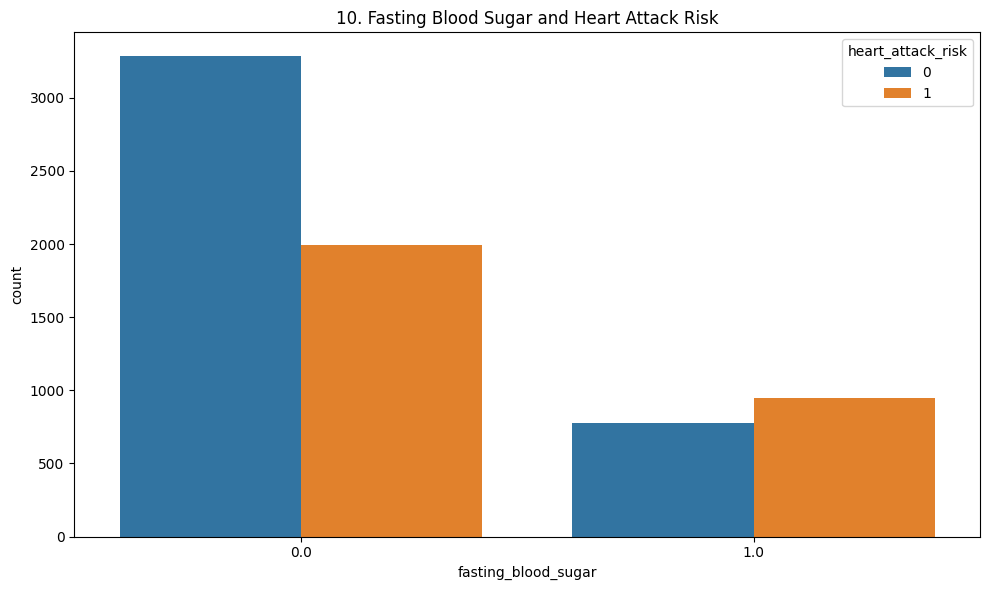

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='fasting_blood_sugar', hue='heart_attack_risk')
plt.title(f'{plot_no}. Fasting Blood Sugar and Heart Attack Risk')
show_fig()
plot_no += 1

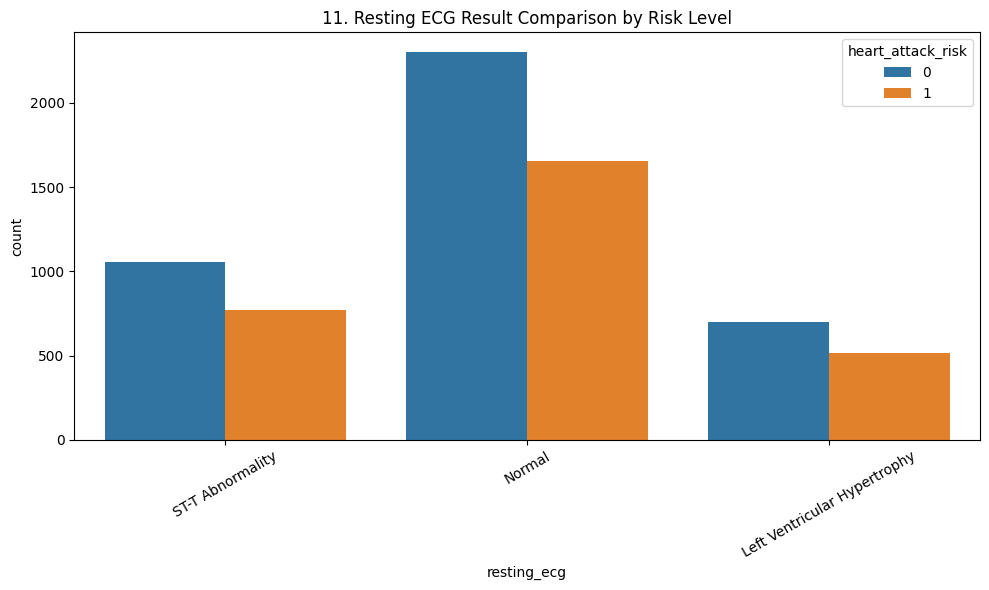

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='resting_ecg', hue='heart_attack_risk')
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Resting ECG Result Comparison by Risk Level')
show_fig()
plot_no += 1

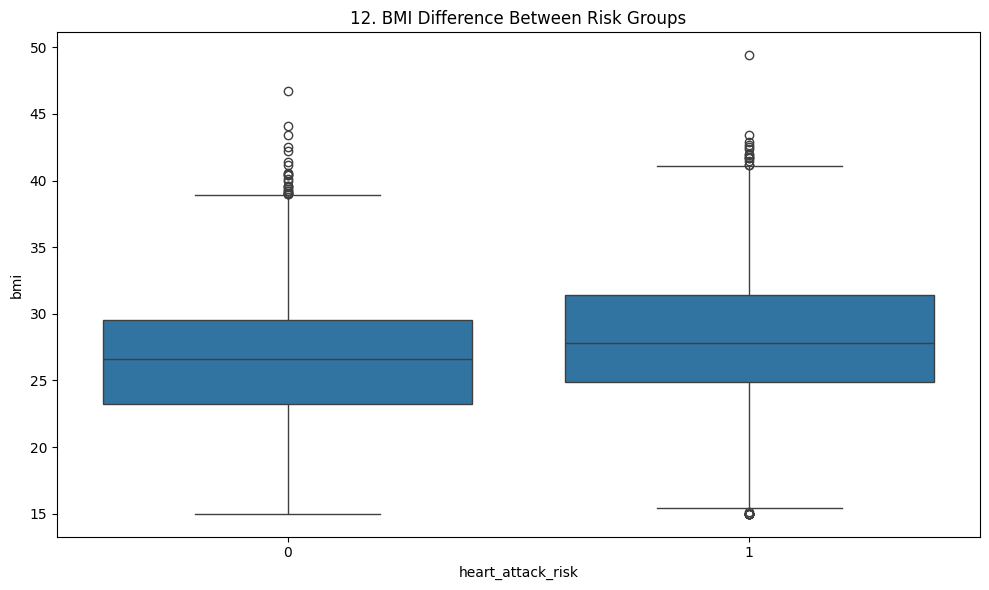

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='heart_attack_risk', y='bmi')
plt.title(f'{plot_no}. BMI Difference Between Risk Groups')
show_fig()
plot_no += 1

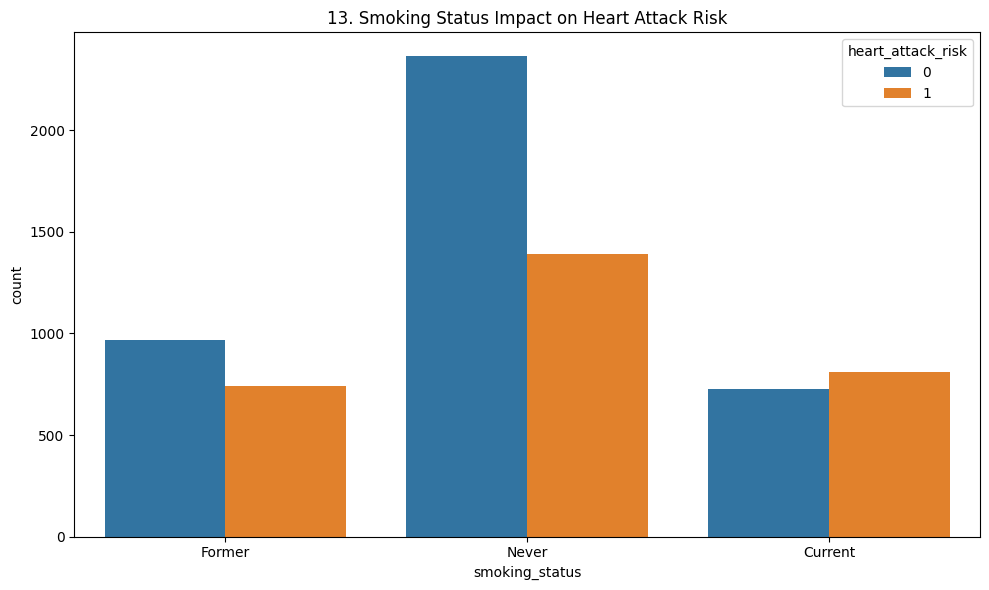

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='smoking_status', hue='heart_attack_risk')
plt.title(f'{plot_no}. Smoking Status Impact on Heart Attack Risk')
show_fig()
plot_no += 1

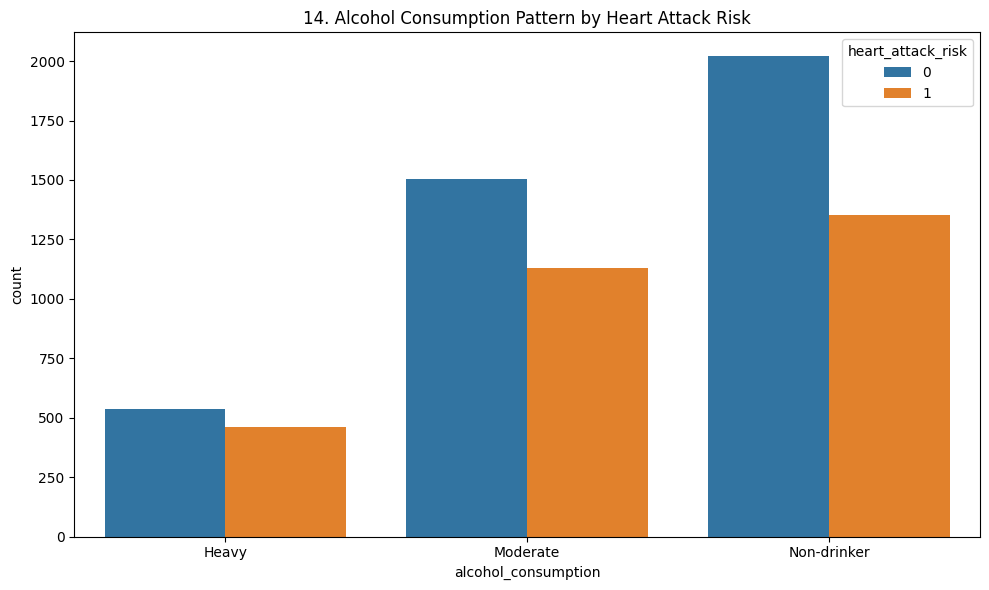

In [32]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='alcohol_consumption', hue='heart_attack_risk')
plt.title(f'{plot_no}. Alcohol Consumption Pattern by Heart Attack Risk')
show_fig()
plot_no += 1

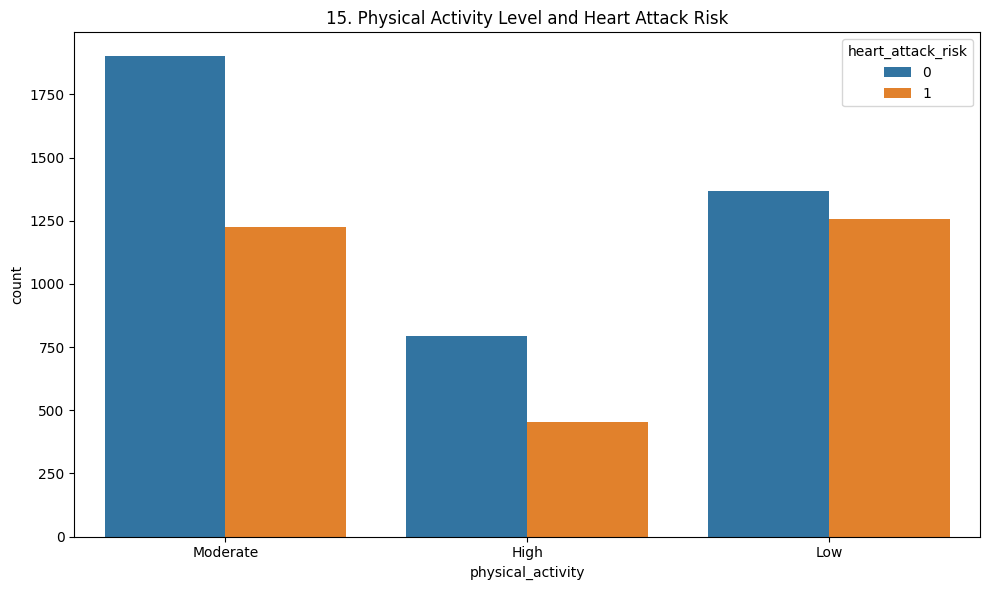

In [33]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='physical_activity', hue='heart_attack_risk')
plt.title(f'{plot_no}. Physical Activity Level and Heart Attack Risk')
show_fig()
plot_no += 1

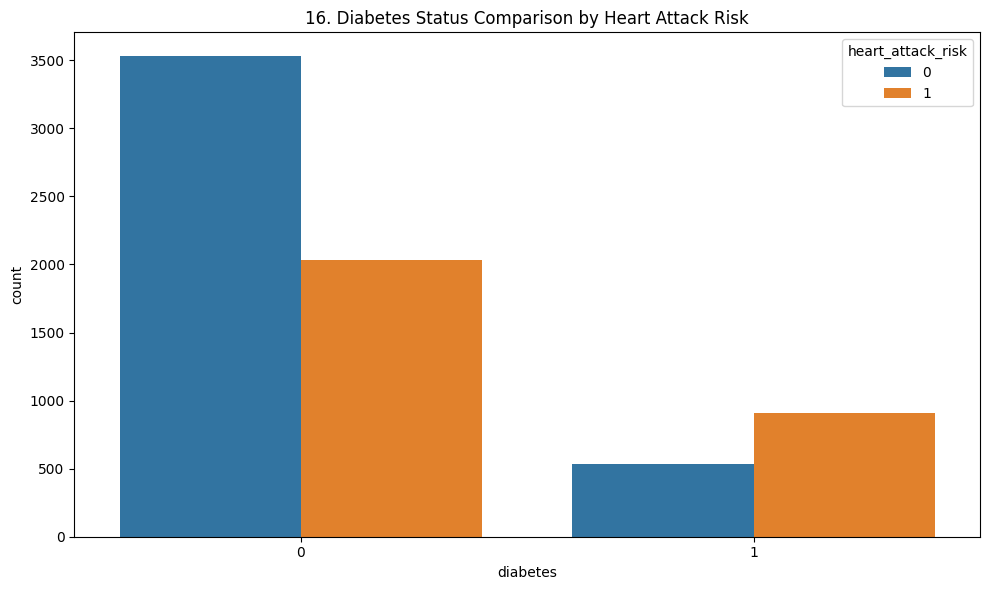

In [34]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='diabetes', hue='heart_attack_risk')
plt.title(f'{plot_no}. Diabetes Status Comparison by Heart Attack Risk')
show_fig()
plot_no += 1

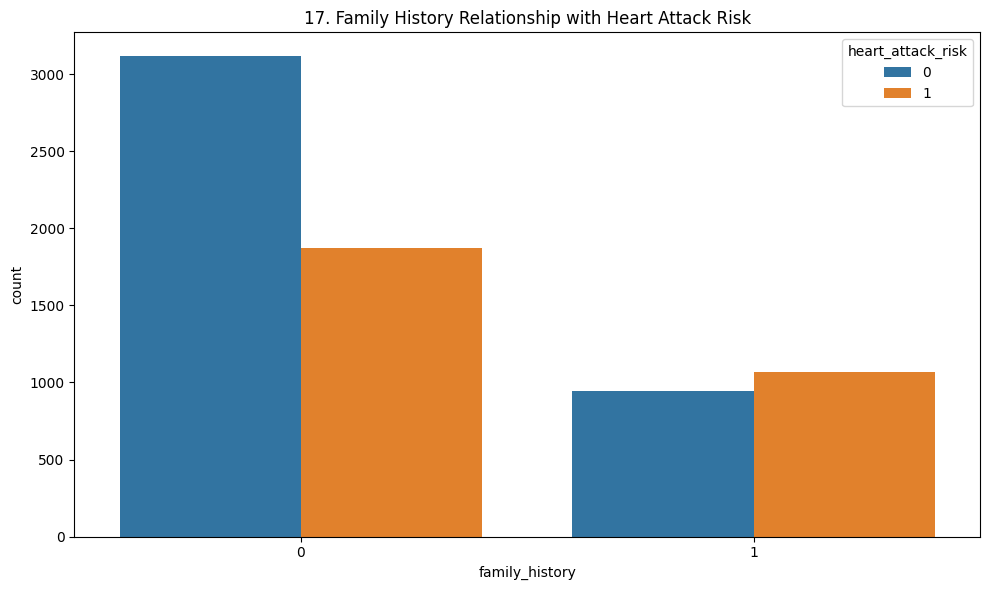

In [35]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='family_history', hue='heart_attack_risk')
plt.title(f'{plot_no}. Family History Relationship with Heart Attack Risk')
show_fig()
plot_no += 1

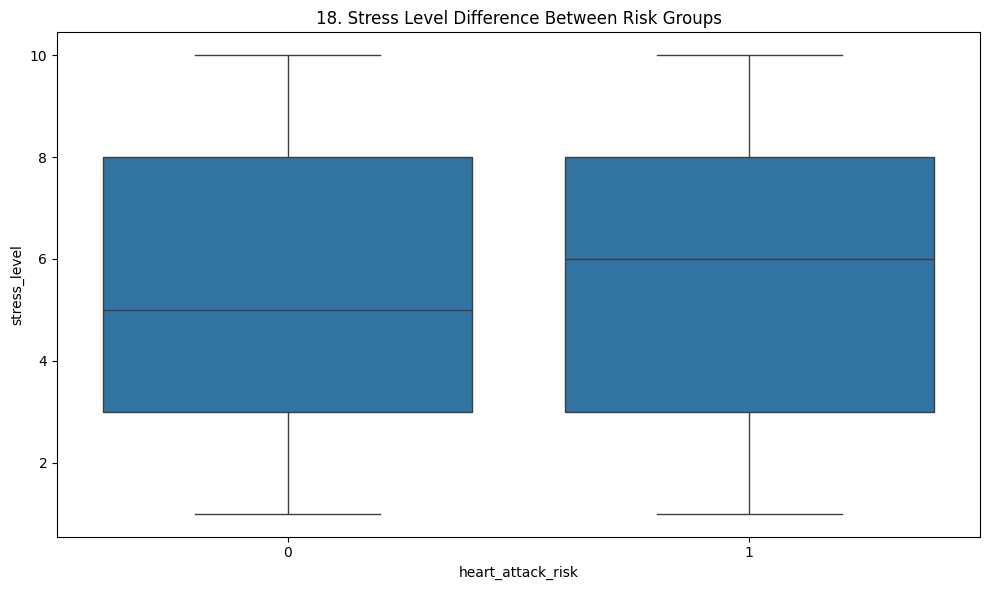

In [36]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='heart_attack_risk', y='stress_level')
plt.title(f'{plot_no}. Stress Level Difference Between Risk Groups')
show_fig()
plot_no += 1

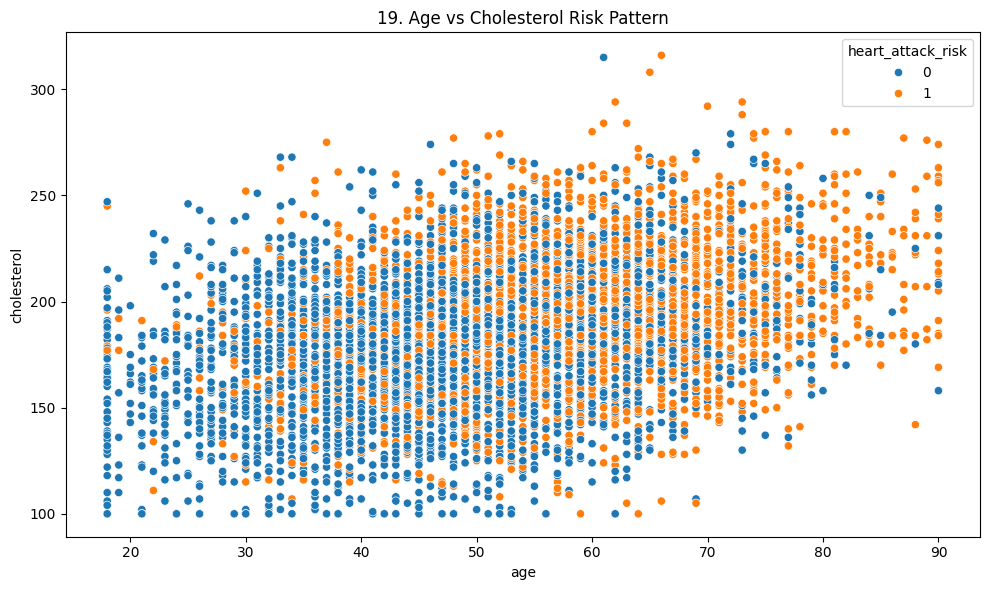

In [37]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='cholesterol', hue='heart_attack_risk')
plt.title(f'{plot_no}. Age vs Cholesterol Risk Pattern')
show_fig()
plot_no += 1

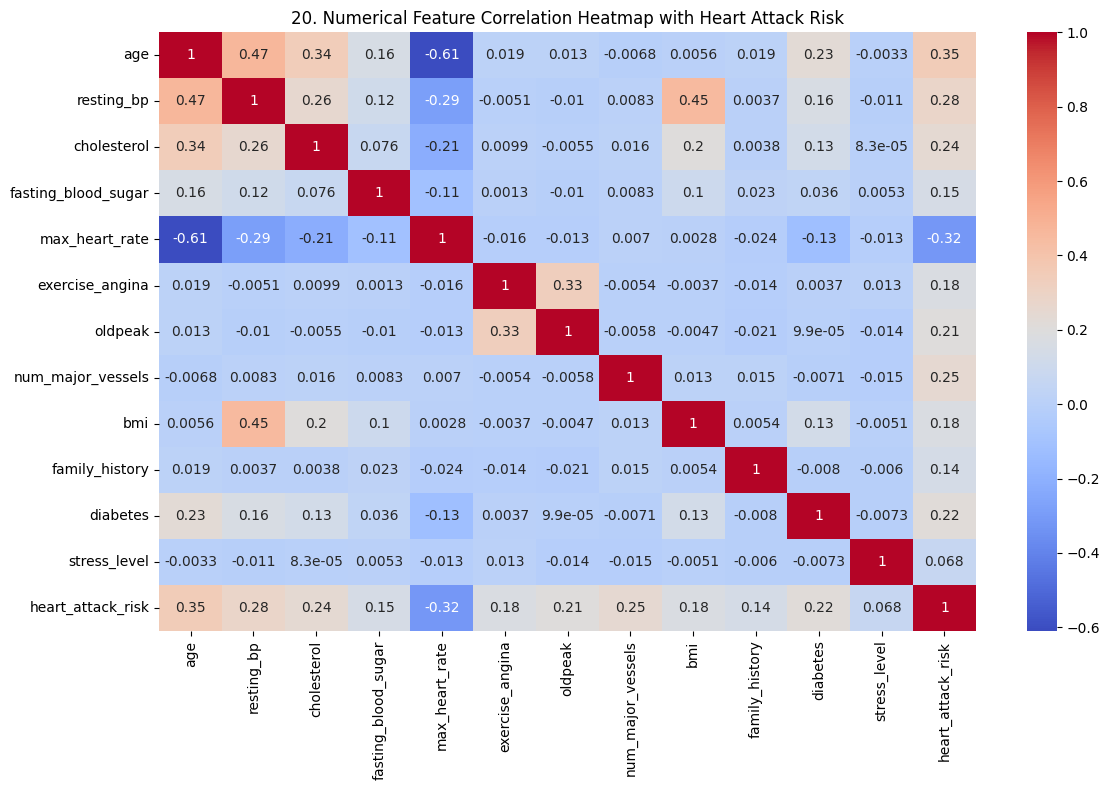

In [38]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Numerical Feature Correlation Heatmap with Heart Attack Risk')
show_fig()
plot_no += 1

# Model Training

## Create feature and target data

In [39]:
X = df.drop(columns=['heart_attack_risk'], errors='ignore')
y = df['heart_attack_risk']

## Remove ID column if present

In [40]:
X = X.drop(columns=['patient_id'], errors='ignore')

## Convert categorical columns into numeric columns

In [41]:
X = pd.get_dummies(X, drop_first=True)

## Split data into training and testing parts

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scale feature values

In [43]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Create logistic regression model

In [44]:
model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42
)

## Train model

In [45]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Predict test data

In [46]:
y_pred = model.predict(X_test)

## Calculate accuracy

In [47]:
accuracy = accuracy_score(y_test, y_pred)

## Print rounded accuracy score

In [48]:
print(f"Accuracy Score: {round(accuracy * 100)}%")

Accuracy Score: 79%


## Print classification report

In [49]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       812
           1       0.77      0.70      0.73       588

    accuracy                           0.79      1400
   macro avg       0.78      0.77      0.78      1400
weighted avg       0.78      0.79      0.78      1400



## Plot confusion matrix

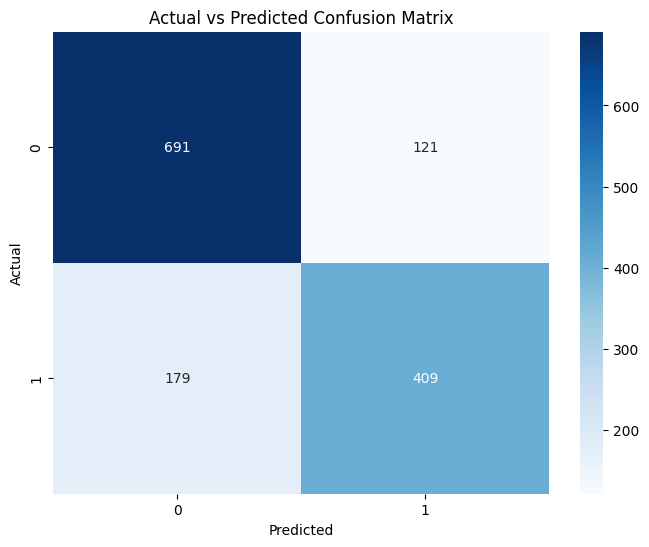

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Actual vs Predicted Confusion Matrix")
plt.show()